# Supplementary Data Figure 3

Environment: env1

In [2]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import re



import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

### plot settings

In [3]:
dpi = 300
font_size = 22
fig_size = 5

In [4]:
def classification_metrics(cases_pos, cases_neg, controls_pos, controls_neg):
    """
    Compute classification metrics from case/control predicted counts.
 
    Parameters
    ----------
    cases_pos    : int | float  — cases predicted positive    (True Positives)
    cases_neg    : int | float  — cases predicted negative    (False Negatives)
    controls_pos : int | float  — controls predicted positive (False Positives)
    controls_neg : int | float  — controls predicted negative (True Negatives)
 
    Returns
    -------
    dict with keys:
        TP, FP, TN, FN,
        TPR  (sensitivity / recall),
        FPR  (fall-out),
        PPV  (precision),
        NPV,
        F1
    """
    TP = cases_pos
    FN = cases_neg
    FP = controls_pos
    TN = controls_neg
 
    TPR = TP / (TP + FN) if (TP + FN) > 0 else float("nan")   # sensitivity
    FPR = FP / (FP + TN) if (FP + TN) > 0 else float("nan")   # fall-out
    PPV = TP / (TP + FP) if (TP + FP) > 0 else float("nan")   # precision
    NPV = TN / (TN + FN) if (TN + FN) > 0 else float("nan")
    F1  = (2 * PPV * TPR) / (PPV + TPR) if (PPV + TPR) > 0 else float("nan")
 
    return {
        "TP":  TP,
        "FP":  FP,
        "TN":  TN,
        "FN":  FN,
        "TPR": TPR,   # sensitivity / recall
        "FPR": FPR,
        "PPV": PPV,   # precision
        "NPV": NPV,
        "F1":  F1,
    }

### test plots

In [5]:
def get_test_roc(label, prob, color="black", curve_label="", rand=False, 
                            x_ticks=True, y_ticks=True, x_label=True, y_label=True):
    label = np.array(label)
    prob = np.array(prob)

    auroc = roc_auc_score(label, prob)

    # roc
    fpr_curve, tpr_curve, _ = roc_curve(label, prob)
    plt.xlim(0, 1)
    plt.ylim(0.00000001, 1)
    if x_label:
        plt.xlabel('FPR', fontsize=font_size)#False Positive Rate (1- Specificity)
    if y_label:
        plt.ylabel('TPR', fontsize=font_size)#True Positive Rate (Sensitivity)
    plt.grid(True, alpha=0.3)
    if len(curve_label)>0:
        plt.plot(fpr_curve, tpr_curve, color=color, lw=2, label=f'{curve_label} (AUC = {auroc:.2f})')
    else:
        plt.plot(fpr_curve, tpr_curve, color=color, lw=2, label=f'AUC = {auroc:.2f}')
    if rand:
        plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label="Rand (AUC = 0.5)")
    ax = plt.gca()
    ax.tick_params(axis='both',labelsize=font_size)
    if not x_ticks:
        ax.set_xticklabels([])
    if not y_ticks:
        ax.set_yticklabels([])
    plt.legend(loc='lower right', fontsize=(font_size-2))
    return auroc

def get_test_pr(label, prob, color="black", curve_label="", rand=False,
                x_ticks=True, y_ticks=True, x_label=True, y_label=True):
    label = np.array(label)
    prob = np.array(prob)

    ap = average_precision_score(label, prob)

    # roc
    fpr_curve, tpr_curve, _ = roc_curve(label, prob)
    precision_curve, recall_curve, _ = precision_recall_curve(label, prob)
    if len(curve_label)>0:
        plt.plot(recall_curve, precision_curve, color=color, lw=2, label=f'{curve_label} (AP = {ap:.2f})')
    else:
        plt.plot(recall_curve, precision_curve, color=color, lw=2, label=f'AP = {ap:.2f}')
    baseline = label.sum() / len(label)
    if rand:
        plt.axhline(y=baseline, color='grey', lw=1, linestyle='--', label=f'Rand (AP = {baseline:.2f})')
    if x_label:
        plt.xlabel('Recall', fontsize=font_size) #Recall (Sensitivity)
    if y_label:
        plt.ylabel('Precision', fontsize=font_size) #Precision (PPV)
    plt.xlim(0, 1)
    plt.ylim(0.00000001, 1)

    ax = plt.gca()
    ax.tick_params(axis='both',labelsize=font_size)
    if not x_ticks:
        ax.set_xticklabels([])
    if not y_ticks:
        ax.set_yticklabels([])
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower left', fontsize=(font_size-2))
    return ap

### get test metrics

In [6]:
def roc_helper(column_start, all_data, n_points, ci_type, add_col, pw=10):
    mean_fpr = np.linspace(0, 1, n_points)

    tpr_list = []
    aucs = []

    for pw in range(1, pw + 1):
        column = f"{column_start}_{pw}"
        subset = all_data[[column, "label"] + add_col].dropna()
        probs = np.array(list(subset[[column] + add_col].mean(axis=1)))
        truths = np.array(list(subset["label"]))
        try:

            fpr, tpr, _ = roc_curve(truths, probs)
            roc_auc = roc_auc_score(truths, probs)
            aucs.append(roc_auc)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tpr_list.append(interp_tpr)
        except:
            pass

    tpr_array = np.array(tpr_list)
    mean_tpr = np.mean(tpr_array, axis=0)
    mean_tpr[-1] = 1.0

    if ci_type == 'std':
        error = np.std(tpr_array, axis=0)
        label = '±1 std. dev.'
    elif ci_type == '95ci':
        error = sem(tpr_array, axis=0) * 1.96
        label = '95% CI'
    else:
        raise ValueError("ci_type must be 'std' or '95ci'")

    upper = np.minimum(mean_tpr + error, 1)
    lower = np.maximum(mean_tpr - error, 0)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    return mean_fpr, mean_tpr, mean_auc, std_auc, lower, upper


def plot_avg_roc_from_dicts(all_data, title='', color="black", n_points=100, ci_type='95ci', 
                            add_col=[], plot=True, pw=10, rand=False, 
                            x_ticks=True, y_ticks=True, x_label=True, y_label=True):
    # retinal
    label = ""
    mean_fpr, mean_tpr, mean_auc, std_auc, lower, upper = roc_helper("pw", all_data, n_points, ci_type, add_col, pw)
    if plot:
        plt.fill_between(mean_fpr, lower, upper, color=color, alpha=0.2, label=label)
        if len(title)>0:
            plt.plot(mean_fpr, mean_tpr, color=color,
                    label=f'{title} (AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2)
        else:
            plt.plot(mean_fpr, mean_tpr, color=color,
                    label=f'AUC = {mean_auc:.2f} ± {std_auc:.2f}', lw=2)            

        ax = plt.gca()
        if rand:
            plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label="Rand (AUC = 0.5)")
        plt.xlim(0, 1)
        plt.ylim(0.00000001, 1)
        if x_label:
            plt.xlabel('FPR', fontsize=font_size) #False Positive Rate (1- Specificity)
        if y_label:
            plt.ylabel('TPR', fontsize=font_size) #True Positive Rate (Sensitivity)
        plt.title(title)
        ax.tick_params(labelsize=font_size)
        if not x_ticks:
            ax.set_xticklabels([])
        if not y_ticks:
            ax.set_yticklabels([])
        plt.legend(loc='lower right', fontsize=(font_size-2))
        plt.grid(True, alpha=0.3)
    return mean_auc


def pr_helper(column_start, all_data, n_points, ci_type, add_col, pw=10):
    mean_recall = np.linspace(0, 1, n_points)

    precision_list = []
    aps = []

    for pw in range(1, pw):
        column = f"{column_start}_{pw}"
        subset = all_data[[column, "label"] + add_col].dropna()
        probs = np.array(list(subset[[column] + add_col].mean(axis=1)))
        truths = np.array(list(subset["label"]))
        try:

            precision, recall, _ = precision_recall_curve(truths, probs)
            ap = average_precision_score(truths, probs)
            aps.append(ap)
            interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
            precision_list.append(interp_precision)
        except:
            pass

    precision_array = np.array(precision_list)
    mean_precision = np.mean(precision_array, axis=0)

    if ci_type == 'std':
        error = np.std(precision_array, axis=0)
        label = '±1 std. dev.'
    elif ci_type == '95ci':
        error = sem(precision_array, axis=0) * 1.96
        label = '95% CI'
    else:
        raise ValueError("ci_type must be 'std' or '95ci'")

    upper = np.minimum(mean_precision + error, 1)
    lower = np.maximum(mean_precision - error, 0)

    mean_ap = np.mean(aps)
    std_ap = np.std(aps)

    return mean_recall, mean_precision, mean_ap, std_ap, lower, upper


def plot_avg_pr_from_dicts(all_data, title='', color="black", n_points=100, ci_type='95ci', 
                           add_col=[], plot=True, pw=10, rand=False,
                           x_ticks=True, y_ticks=True, x_label=True, y_label=True):
    # retinal
    label = ""
    mean_recall, mean_precision, mean_ap, std_ap, lower, upper = pr_helper("pw", all_data, n_points, ci_type, add_col, pw)
    if plot:
        plt.fill_between(mean_recall, lower, upper, color=color, alpha=0.2, label=label)
        if len(title)>0:
            plt.plot(mean_recall, mean_precision, color=color,
                    label=f'{title} (AP = {mean_ap:.2f} ± {std_ap:.2f})', lw=2)
        else:
            plt.plot(mean_recall, mean_precision, color=color,
                    label=f'AP = {mean_ap:.2f} ± {std_ap:.2f}', lw=2)

        ax = plt.gca()
        if x_label:
            plt.xlabel('Recall', fontsize=font_size) #Recall (Sensitivity)
        if y_label:
            plt.ylabel('Precision', fontsize=font_size) #Precision (PPV)

        plt.xlim(0, 1)
        plt.ylim(0.00000001, 1)

        plt.title(title)
        # pos / (avg num pw controls + hc + pos)
        if rand:
            val = sum(list(all_data['label'])) / ((len(all_data) - len(all_data[all_data["label"] == 0].dropna()) - sum(list(all_data['label']))) / pw + len(all_data[all_data["label"] == 0].dropna()) + sum(list(all_data['label'])))
            if title == "GHTN":
                plt.axhline(val, linestyle='--', color='grey', label=f"GHTN Random (AP = {val:.2f})")
            elif title == "CHTN":
                plt.axhline(val, linestyle='-', color='grey', label=f"CHTN Random (AP = {val:.2f})")
            else:
                plt.axhline(val, linestyle='-', color='grey', label=f"Rand (AP = {val:.2f})")
        plt.legend(loc='lower left', fontsize=(font_size-2))
        ax.tick_params(labelsize=font_size)
        if not x_ticks:
            ax.set_xticklabels([])
        if not y_ticks:
            ax.set_yticklabels([])
        plt.grid(True, alpha=0.3)
    return mean_ap

In [7]:



        
def strings_to_na(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def gest_age_to_days(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Convert gestational age strings like '12w1d', '9w', '3d'
    into total days as a numeric column.
    Invalid or missing values -> NaN.
    """
    pattern = re.compile(r'^\s*(?:(\d+)\s*w)?\s*(?:(\d+)\s*d)?\s*$', re.I)

    def parse(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return x  # already numeric (assume days)
        
        if ' ' in x:
            x = x.split(' ')[0]
        m = pattern.match(str(x))
        if not m:
            return np.nan
        weeks = int(m.group(1)) if m.group(1) else 0
        days = int(m.group(2)) if m.group(2) else 0
        return weeks * 7 + days
    
    df = df.copy()

    df[col] = df[col].apply(parse).astype('float')
    return df

def datetime_to_day_index(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Convert a datetime column into integer days since the earliest date.
    Earliest date -> 0, next day -> 1, etc.
    """
    # Ensure datetime
    dt = pd.to_datetime(df[col], errors='coerce')

    # Normalize to date (drop time-of-day)
    dt = dt.dt.normalize()

    # Compute day index
    df[col] = (dt - dt.min()).dt.days

    return df


def process_ethnicity(eth: str):
    """
    Parse a free-text ethnicity string into:
    - race: White / Black / Asian / Multiracial / Other / Unknown
    - ethnicity: hispanic / not hispanic
    """
    if not isinstance(eth, str) or not eth.strip():
        return "Unknown", "not hispanic"

    s = eth.lower()
    
    if eth == 'laotian':
        return('asian', 'not hispanic')

    races = ['white', 'black', 'asian']
    found = [r for r in races if r in s]

    # Determine race
    if len(found) > 1:
        race = 'Multiracial'
    elif len(found) == 1:
        race = found[0].capitalize()
    else:
        race = 'Other'

    # Determine ethnicity
    if 'hispanic' in s and 'not' not in s:
        ethnicity = 'hispanic'
    else:
        ethnicity = 'not hispanic'

    return race, ethnicity

import pandas as pd

def add_ethnicity_binaries(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    From a free-text ethnicity column, add binary columns:
    White, Black, Asian, Multiracial, Hispanic
    """
    parsed = df[col].apply(process_ethnicity)
    parsed_df = pd.DataFrame(parsed.tolist(), columns=['race', 'ethnicity'], index=df.index)

    race = parsed_df['race'].fillna('').str.lower()
    ethnicity = parsed_df['ethnicity'].fillna('').str.lower()

    df['Maternal Race_White'] = (race == 'white').astype(int)
    df['Maternal Race_Black'] = (race == 'black').astype(int)
    df['Maternal Race_Asian'] = (race == 'asian').astype(int)
    df['Maternal Race_Multiracial'] = (race == 'multiracial').astype(int)
    df['Maternal Race_Other'] = (~race.isin(['white', 'black', 'asian', 'multiracial'])).astype(int)

    df['Maternal hispanic'] = (ethnicity == 'hispanic').astype(int)

    return df

def proc_smoker(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df[col] = df[col].apply(lambda x: 0 if 'never' in x.lower() else 1)
    return df

def proc_conception(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df['IVF'] = df[col].apply(lambda x: 1 if 'ivf' in x.lower() and 'natural' not in x.lower() else 0)
    return df    


def proc_on_yes(df: pd.DataFrame, col: str) -> pd.DataFrame:
    def parse(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, str):
            if 'yes' in x.lower():
                return(1)
            else:
                return(0)
        
    df[col] = df[col].apply(parse)
    return df  


def proc_on_no(df: pd.DataFrame, col: str) -> pd.DataFrame:
    def parse(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, str):
            if 'no' in x.lower():
                return(0)
            else:
                return(1)
        
    df[col] = df[col].apply(parse)
    return df


def proc_birth_hx(df: pd.DataFrame, col: str) -> pd.DataFrame:
    def parse(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, str):
            if 'healthy' in x.lower():
                return(0)
            elif 'pe' in x.lower():
                return(1)     
            elif 'gdm' in x.lower():
                return(2)
            elif 'ghtn' in x.lower():
                return(3)
               
        
    df[col] = df[col].apply(parse)
    df['Past Preeclampsia'] = df[col].apply(lambda x: 1 if x==1 else 0)
    df['Past Gestational HTN'] = df[col].apply(lambda x: 1 if x==3 else 0)
    df['Past Gestational diabetes'] = df[col].apply(lambda x: 1 if x==2 else 0)
    
    return df


def get_ipp(df: pd.DataFrame, col: str, date_col: str) -> pd.DataFrame: # inter preg period
    dt = pd.to_datetime(df[date_col], errors='coerce')
    prev_preg = pd.to_datetime(df[col], errors='coerce')

    # Normalize to date (drop time-of-day)
    dt = dt.dt.normalize()
    prev_preg = prev_preg.dt.normalize()

    # Compute day index
    df['ipp'] = (dt - prev_preg).dt.days

    return df

def split_bp(df: pd.DataFrame, col: str) -> pd.DataFrame:
    def parse(x):
        sbp = int(x.split('/')[0])
        dbp = int(x.split('/')[1])
        return(sbp, dbp)
    df['sbp'] = df[col].apply(lambda x: parse(x)[0])
    df['dbp'] = df[col].apply(lambda x: parse(x)[1])
    return(df)

def get_ama(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df['ama'] = (df[col] > 35.).astype(int)
    df['ama_custom'] = (df[col] > 35.).astype(int)
    return(df)

def get_bmi(df: pd.DataFrame, weight_col: str, height_col: str) -> pd.DataFrame:
    df['bmi'] = df[weight_col]/(df[height_col]**2)
    return(df)


def proc_db(df: pd.DataFrame, col: str) -> pd.DataFrame:
    
    def parse(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, str):
            if '1' in x:
                return 1
            elif '2' in x:
                return 2
            else:
                return 0
        
    df[col] = df[col].apply(parse)
    df['Diabetes_type1'] = df[col].apply(lambda x: 1 if x==1 else 0)
    df['Diabetes_type2'] = df[col].apply(lambda x: 1 if x==2 else 0)
    return(df)

### load data

In [8]:
fmf_loo = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_cu.csv")
fmf_loo["fmf_prob"] = fmf_loo["pe_before_delivery_percent"] / 100
fmf_loo["id"] = [id.lower() for id in fmf_loo["patient_id"]]
fmf_loo = fmf_loo[["fmf_prob", "id"]]

In [9]:
clinical_unproc = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_features_all_20250930.csv", index_col=0)
clinical_unproc = clinical_unproc.rename(columns={'Study ID':'id'})

In [10]:
clinical_unproc = clinical_unproc[['id','Maternal hispanic',
       'Maternal Race_Asian', 'Maternal Race_Black',
       'Maternal Race_Multiracial', 'Maternal Race_Other',
       'Maternal Race_Unknown', 'Maternal Race_White']]

In [11]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

### SETTINGS !

In [ ]:
# modify here to choose stratification

strat_type='white_unlabeled'

all_labels = False

run_hispanic = True
run_no_hispanic = False
run_white = False
run_black = False


### CU Stablity model

In [13]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw/run_20260407_stable/meta_probs_auc_0.5/all_pw_metrics.csv")

result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]

In [14]:
cu_all_probs = []
for pw in range(1, 6):
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw{pw}/run_20260407_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [15]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left", on='id')
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left", on='id')
cu_all_probs = cu_all_probs.merge(clinical_unproc, how="left", on='id')

In [16]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    pec = pickle.load(f)
with open("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_test_pec_cases_20260406.pkl", "rb") as f:
    pec_test = pickle.load(f)
all_pec = pec + pec_test
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(6):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [17]:
cu_all_probs['avg_prob'] = cu_all_probs[['pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5']].mean(axis=1)

In [18]:
model_type='stable'

In [19]:
if run_hispanic:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal hispanic']==1]
if run_no_hispanic:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal hispanic']==0]
if run_black:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal Race_Black']==1]
if run_white:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal Race_White']==1]    


In [20]:
# for determining best weights

# best_auc = 0
# best_ap = 0
# best_pp = 0
# best_fp = 0
# best_age = 0
# for pp in np.arange(0, 1.05, 0.05):
#     for fp in np.arange(0, 1.05, 0.05):
#         for age in np.arange(30, 40, 1):
#                 reweight = cu_all_probs.copy()
#                 cols = ["Combo"]
#                 reweight["Combo"] = (reweight["Past PEC"] * pp + fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > age).astype(int)))
#                 auc = plot_avg_roc_from_dicts(reweight, title=f"AVG(Retinal,  {cols} * {pp} {fp}, {age})", add_col=cols, plot=False, pw=5)
#                 ap = plot_avg_pr_from_dicts(reweight, title=f"AVG(Retinal,  {cols} * {pp} {fp} {age})", add_col=cols, plot=False, pw=5)
#                 if auc > best_auc:
#                     best_auc = auc
#                     best_ap = ap
#                     best_pp = pp
#                     best_fp = fp
#                     best_age = age
# "auc", best_auc, "ap", best_ap, "pp", best_pp, "fp", best_fp, "age", best_age

# for cropped
# pp = 0.9500000000000001
# fp = 0.7000000000000001
# age = 37

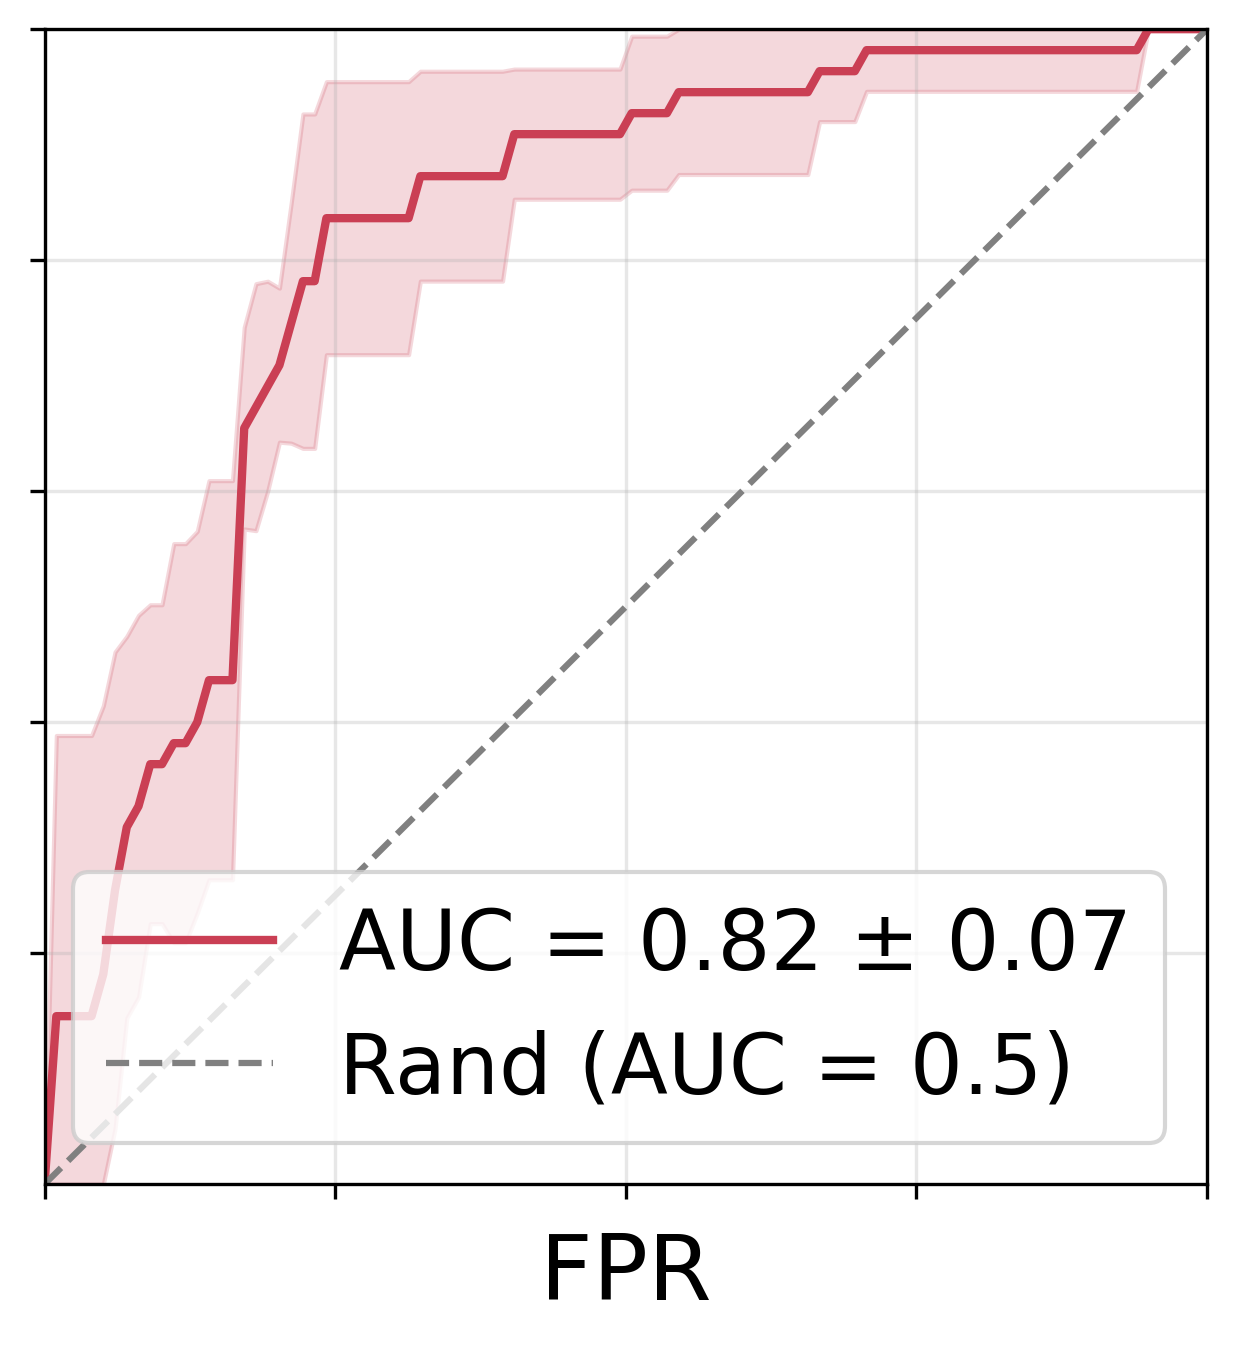

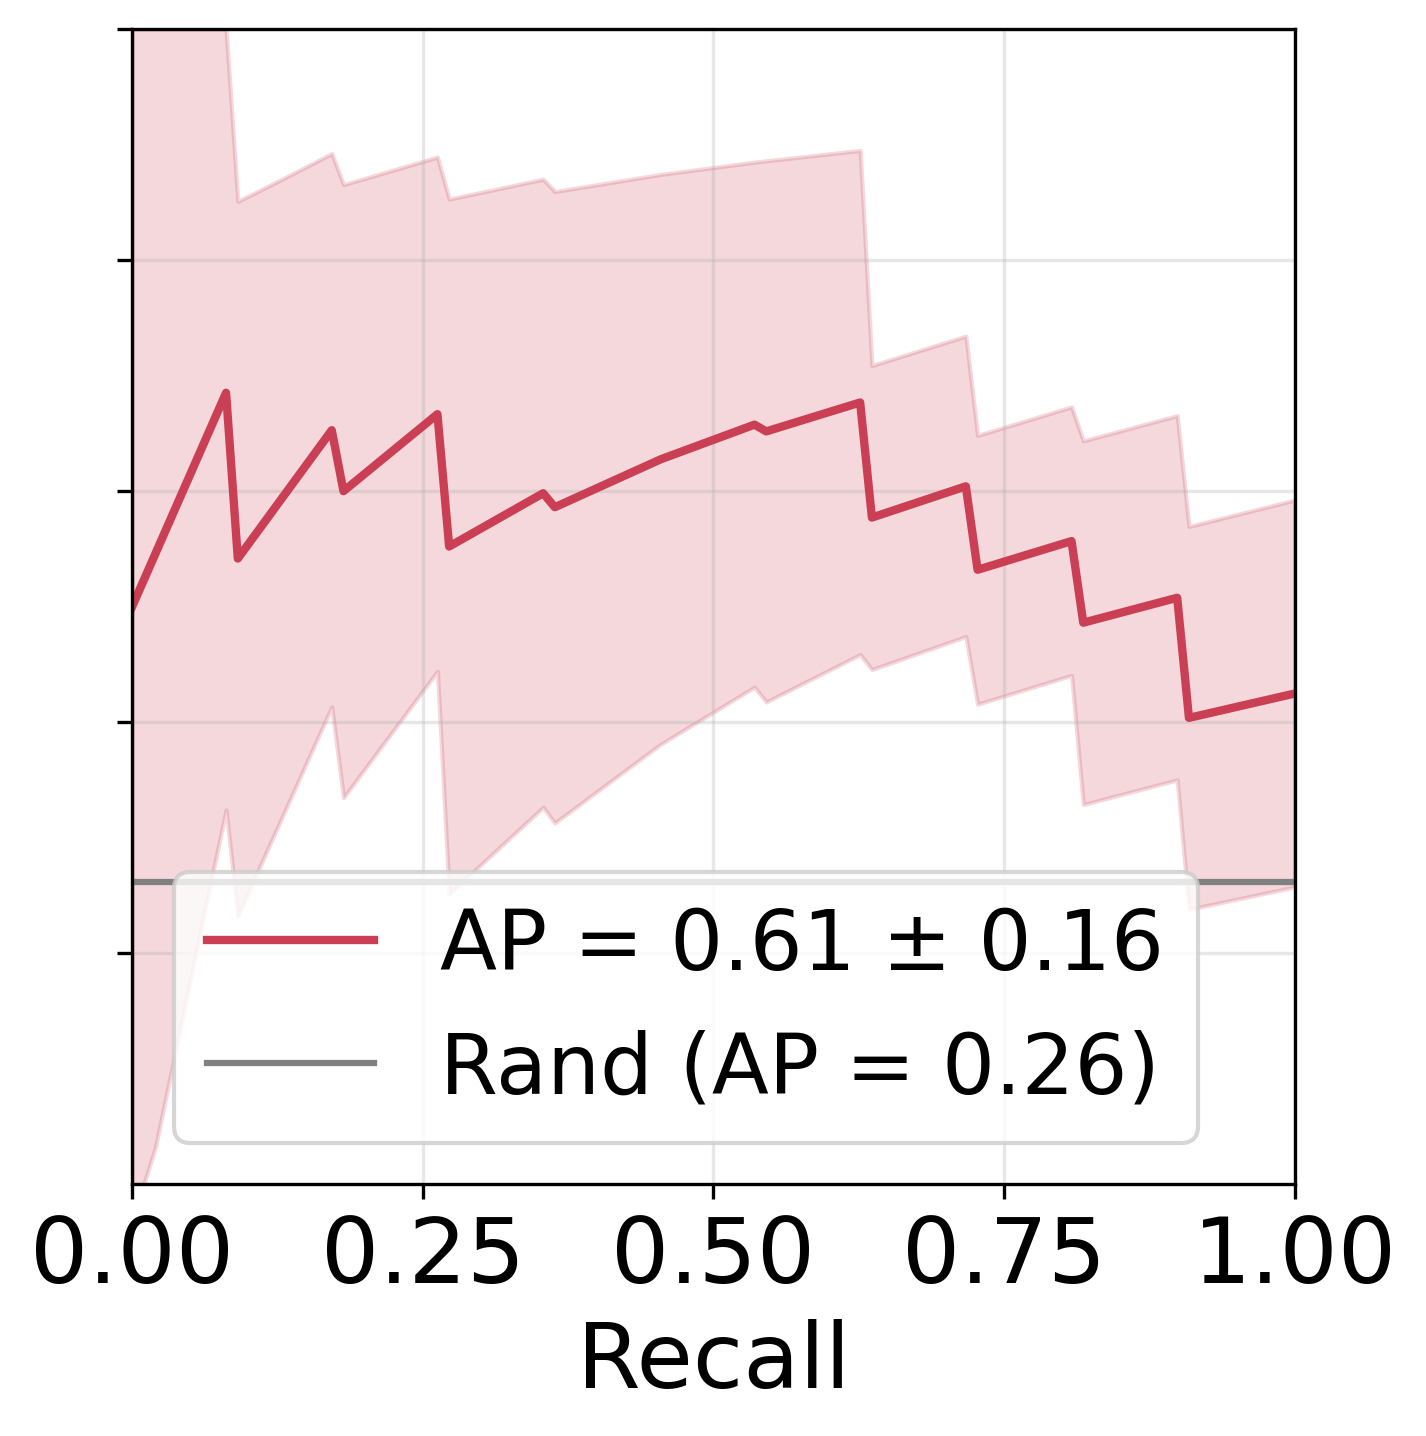

In [21]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                           x_label=True, y_label=True, x_ticks=False, y_ticks=True
                           )#title=f"Retinal",
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                       x_label=True, y_label=False, x_ticks=False, y_ticks=False
                       )#title=f"Retinal",
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_auc.svg') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
    #                        x_label=False, y_label=False, x_ticks=False, y_ticks=False
                          )#title=f"Retinal",
else:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          )#title=f"Retinal",
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_pr.svg') 

plt.show()

### CU Performance model

In [30]:
pw1_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw1/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw2_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw2/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw3_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw3/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw4_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw4/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"
pw5_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw5/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw6_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw6/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_8}_oof.pkl"
pw7_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw7/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_32}_oof.pkl"
pw8_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw8/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_8}_oof.pkl"
pw9_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw9/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw10_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw10/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_32}_oof.pkl"


pw_models = [pw1_5,pw2_5,pw3_5,pw4_5,pw5_5,pw6_5,pw7_5,pw8_5,pw9_5,pw10_5]

In [31]:
cu_all_probs = []
for pw in range(0, 10):
    path = pw_models[pw]
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [32]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left", on='id')
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left", on='id')
cu_all_probs = cu_all_probs.merge(clinical_unproc, how="left", on='id')

In [33]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    pec = pickle.load(f)
with open("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_test_pec_cases_20260406.pkl", "rb") as f:
    pec_test = pickle.load(f)
all_pec = pec + pec_test
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(10):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [34]:
cu_all_probs_o = cu_all_probs.copy()

In [35]:
# cu_all_probs = cu_all_probs.merge(clinical_unproc, on='id', how='inner')

In [36]:
model_type='best'


In [37]:
if run_hispanic:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal hispanic']==1]
if run_no_hispanic:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal hispanic']==0]
if run_black:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal Race_Black']==1]
if run_white:
    cu_all_probs = cu_all_probs[cu_all_probs['Maternal Race_White']==1]  

In [38]:
cu_all_probs['avg_prob'] = cu_all_probs[['pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5',
                                         'pw_6', 'pw_7', 'pw_8', 'pw_9', 'pw_10']].mean(axis=1)

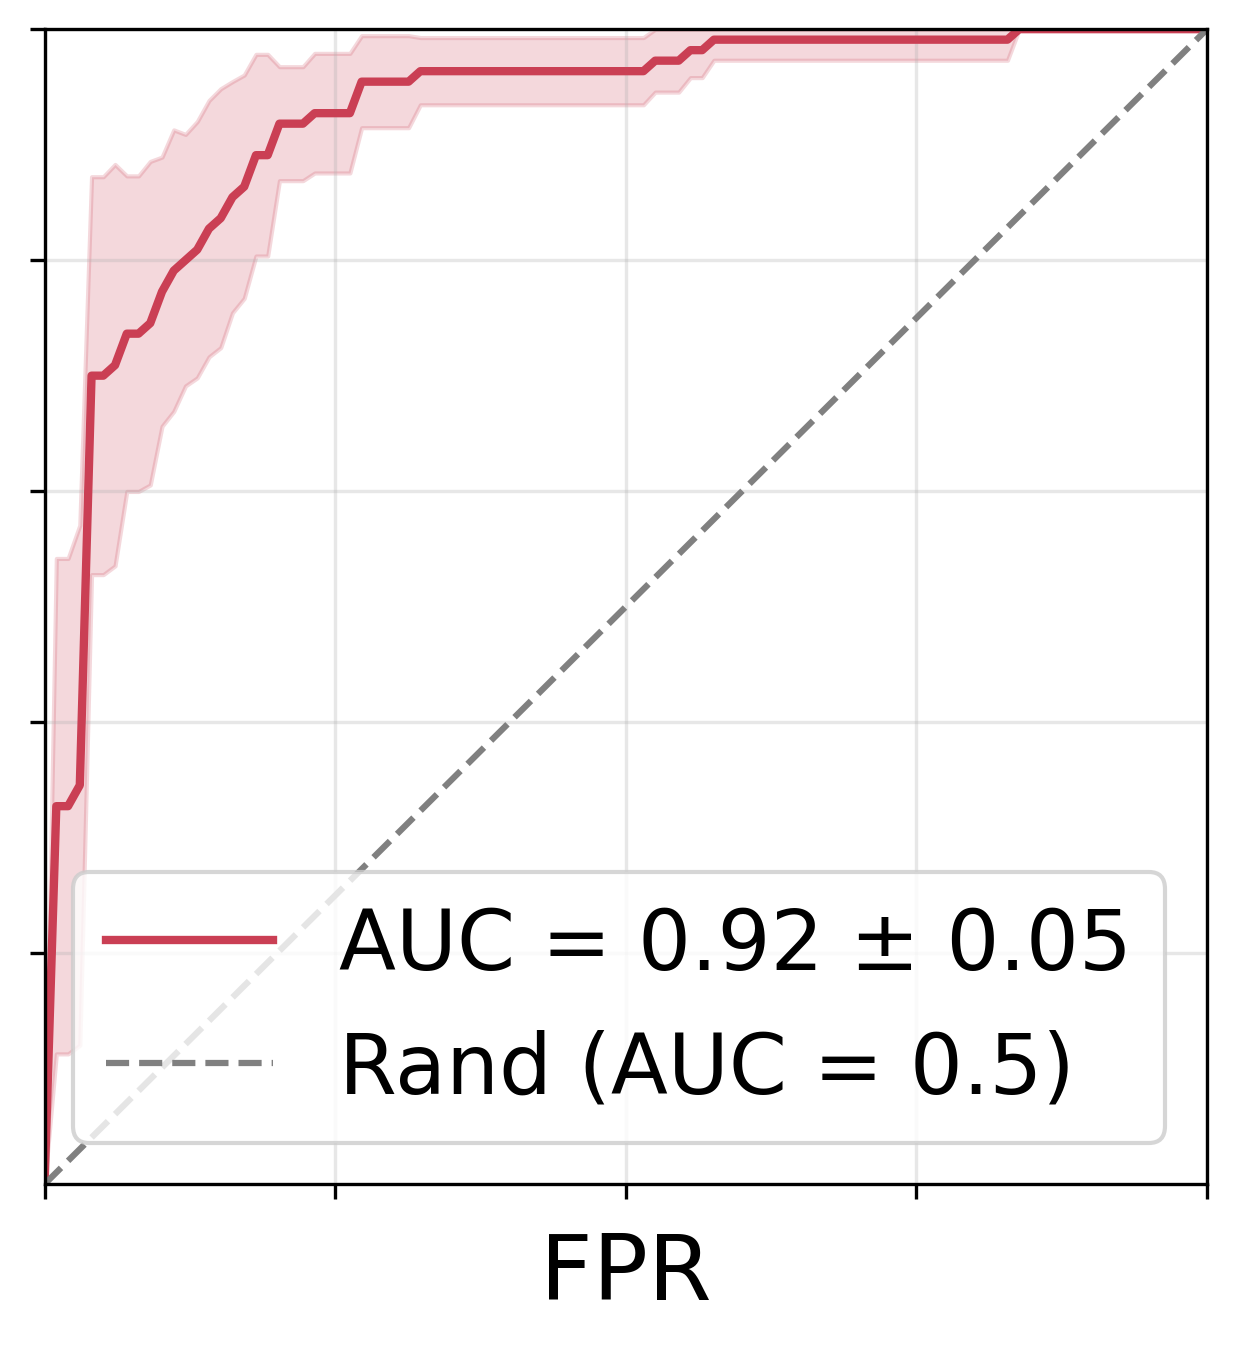

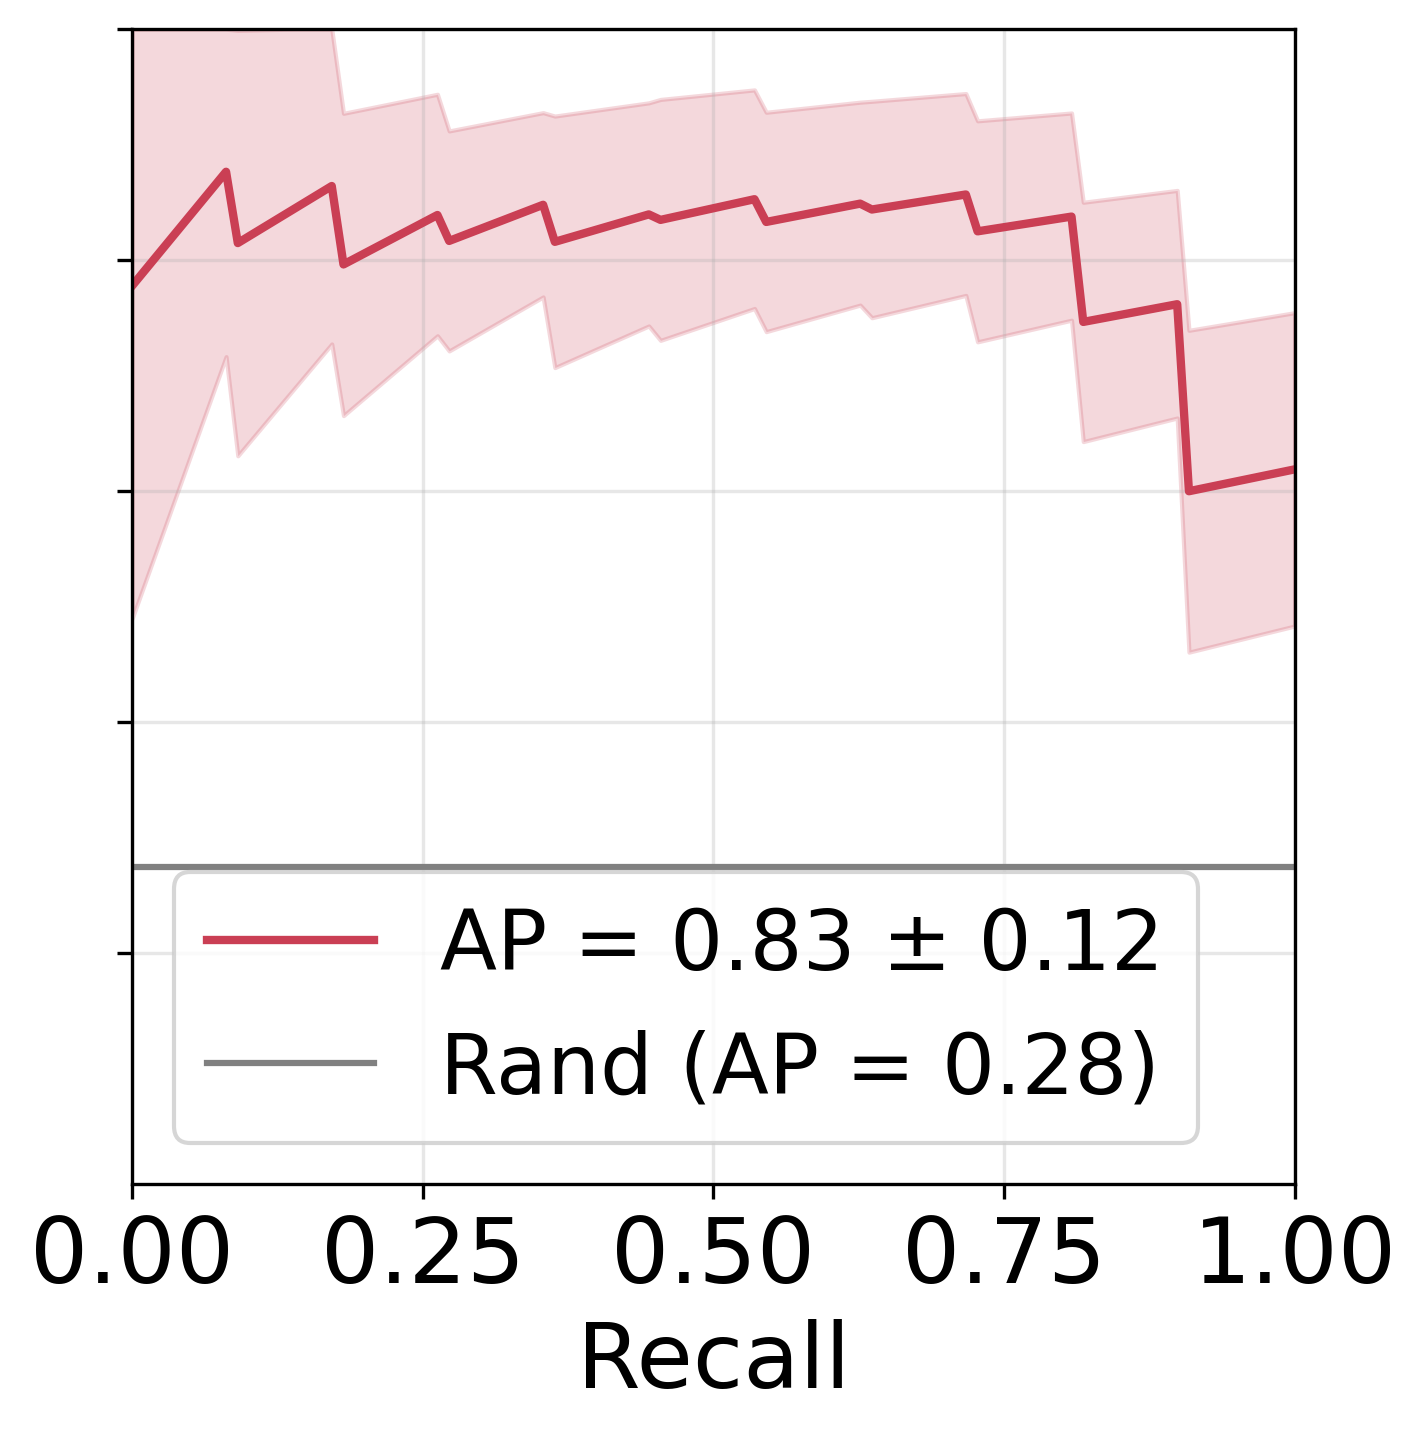

In [39]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                            x_label=True, y_label=True, x_ticks=False, y_ticks=True
                           )#title=f"Retinal",
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                            x_label=True, y_label=False, x_ticks=False, y_ticks=False
                           )#title=f"Retinal",
    
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_auc.svg') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
#                            x_label=False, y_label=False, x_ticks=False, y_ticks=False
                          ) #title=f"Retinal",
else:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          ) #title=f"Retinal",
    
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_pr.svg') 

plt.show()

### nyu

In [40]:
fmf_probs = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results.csv")
fmf_probs["id"] = [id.lower() for id in fmf_probs["patient_id"]]
fmf_probs["first_preg"] = [int(val == "Nulliparous") for val in fmf_probs["input_obhist"]]
fmf_probs["prev_pec"] = [int(val == "Parous, prev PE") for val in fmf_probs["input_obhist"]]

In [41]:

clinical_feats = pd.read_excel(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/Visionary AI Participant Tracker (2).xlsx',sheet_name='FMF Algorithim ')

clinical_feats = clinical_feats.iloc[0:107]


clinical_feats = clinical_feats.rename(columns={'Record ID':'id'}) 
clinical_feats['id'] = clinical_feats['id'].apply(lambda x: x.lower())

clinical_feats = strings_to_na(clinical_feats, 'Height (m)')
clinical_feats = strings_to_na(clinical_feats, 'Weight (kg)')
clinical_feats = gest_age_to_days(clinical_feats, 'GA at Visit 1 ')
clinical_feats = strings_to_na(clinical_feats, 'Age ')
clinical_feats = datetime_to_day_index(clinical_feats,'EDD')
clinical_feats = add_ethnicity_binaries(clinical_feats, 'Ethnicity')
clinical_feats = proc_smoker(clinical_feats, 'Smoking Status ')
clinical_feats = proc_conception(clinical_feats, 'Conception Method ')
clinical_feats = proc_on_yes(clinical_feats, 'cHTN')
clinical_feats = proc_on_yes(clinical_feats, 'Family Hx diabetes ?')
clinical_feats = proc_db(clinical_feats, 'Diabetes?')
clinical_feats = proc_on_no(clinical_feats, 'Diabetic Drugs?')
clinical_feats = proc_on_no(clinical_feats, 'Systemic lupus ')
clinical_feats = proc_on_no(clinical_feats, 'Anti phospholipid syndrome ')
clinical_feats = proc_on_no(clinical_feats, 'Nulliparity?')
clinical_feats = proc_birth_hx(clinical_feats, 'Pts last birth Dx (PEC/GDM, GHTN, Preterm)')

clinical_feats = gest_age_to_days(clinical_feats, 'GA at delivery ')

clinical_feats = get_ama(clinical_feats, 'Age ')
clinical_feats = get_bmi(clinical_feats, 'Weight (kg)', 'Height (m)')
clinical_feats['obesity'] = clinical_feats['bmi'].apply(lambda x: 1 if x>=30 else 0)

clinical_feats['Current Smoker'] = 0
clinical_feats['Maternal Race_Unknown'] = 0


clinical_feats['Past Hypertension'] = clinical_feats['cHTN'].copy()
clinical_feats['Past Preterm Labor'] = 0


In [42]:
clinical_feats = clinical_feats.drop_duplicates()

In [43]:
nyu_clinical_md = pd.read_csv('/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_ml_clinical_features_20260501.csv', index_col=0)

In [44]:
nyu_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/nyu/nyu_rg_delivered_testset/"
nyu_run = "nyu_79_no_repeats_med_pec"

all_probs = []
for i in range(1, 6):
    path = nyu_path + f"{nyu_run}_pw{i}/meta_all_0.5_oof_bls_pw{i}/XGBoost/"
    name = os.listdir(path)[0]
    with open(path + name, "rb") as f:
        data = pickle.load(f)
    all_probs.append(data[1])
all_probs = pd.DataFrame(all_probs)

In [45]:
retinal_probs = pd.DataFrame(all_probs.min(), columns=["retinal"])
retinal_probs["id"] = retinal_probs.index
retinal_probs = retinal_probs.reset_index(drop=True)

retinal_probs = retinal_probs.dropna()

In [46]:
ids = list(set(retinal_probs["id"].values) - set([
"nyu031","nyu062","nyu099","nyu089","nyu078","nyu114","nyu015","nyu061","nyu079","nyu047","nyu017","nyu057",
"nyu063","nyu080","nyu013","nyu067","nyu044","nyu139",])) # to exclude

In [47]:
retinal_probs = retinal_probs[retinal_probs['id'].isin(ids)]

In [48]:
# ids
nyu_cases = pd.read_pickle('/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_cases_051126.pkl')

In [49]:
retinal_probs['label'] = retinal_probs['id'].apply(lambda x: 1 if x in nyu_cases else 0)

In [50]:
retinal_probs_clin = retinal_probs.merge(clinical_feats, on='id')

In [51]:
retinal_probs_clin['label'] = retinal_probs_clin['id'].apply(lambda x: 1 if x in nyu_cases else 0)

In [52]:
model_type = 'stable'

In [53]:
# # hispanic
if run_hispanic:
    retinal_probs_subset = retinal_probs_clin[
        (retinal_probs_clin['Ethnicity'].str.lower().str.contains('hispanic')) & 
        ~(retinal_probs_clin['Ethnicity'].str.lower().str.contains('not'))]

# no hispanic
if run_no_hispanic:
    retinal_probs_subset = retinal_probs_clin[
    (    (retinal_probs_clin['Ethnicity'].str.lower().str.contains('hispanic')) & 
        (retinal_probs_clin['Ethnicity'].str.lower().str.contains('not'))) |
        (~retinal_probs_clin['Ethnicity'].str.lower().str.contains('hispanic'))
    ]

# # white
if run_white:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['Ethnicity'].str.lower().str.contains('white')]

# black
if run_black:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['Ethnicity'].str.lower().str.contains('black')]

/gpfs/data/shenhavlab/users/Daniel/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


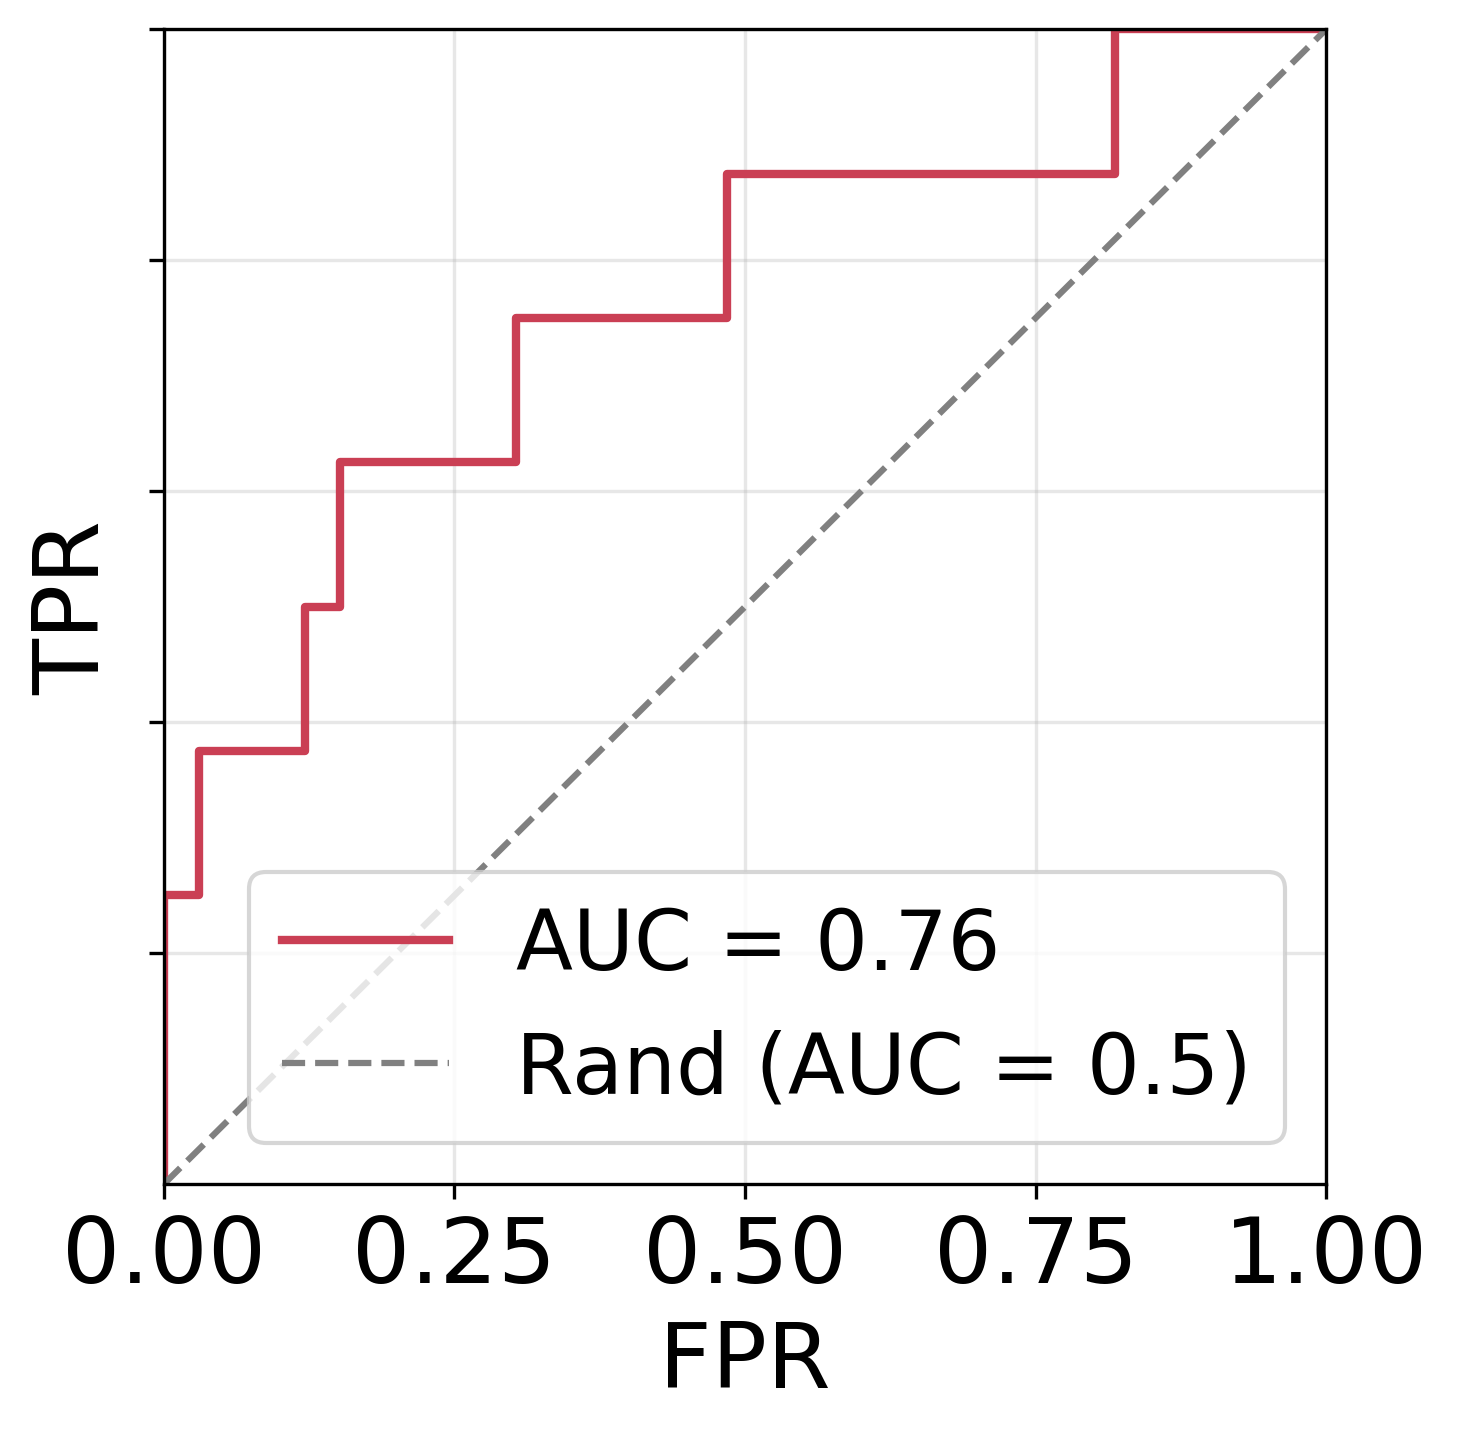

In [54]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
retinal_probs_subset["combo"] = (retinal_probs_subset["Past Preeclampsia"] * 0.35 + 0.15 *((retinal_probs_subset["Nulliparity?"]) * (retinal_probs_subset["Age "] > 37).astype(int)))
retinal_probs_subset_t = retinal_probs_subset[["label","retinal","combo"]]
if all_labels:
    get_test_roc(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                 color="#CA3F54",rand=True,
                 x_label=True, y_label=True, x_ticks=True, y_ticks=True
                );
else:
    get_test_roc(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                 color="#CA3F54",rand=True,
                 x_label=True, y_label=True, x_ticks=True, y_ticks=False
                );

plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_{strat_type}_auc.svg') 
plt.show()

/gpfs/data/shenhavlab/users/Daniel/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


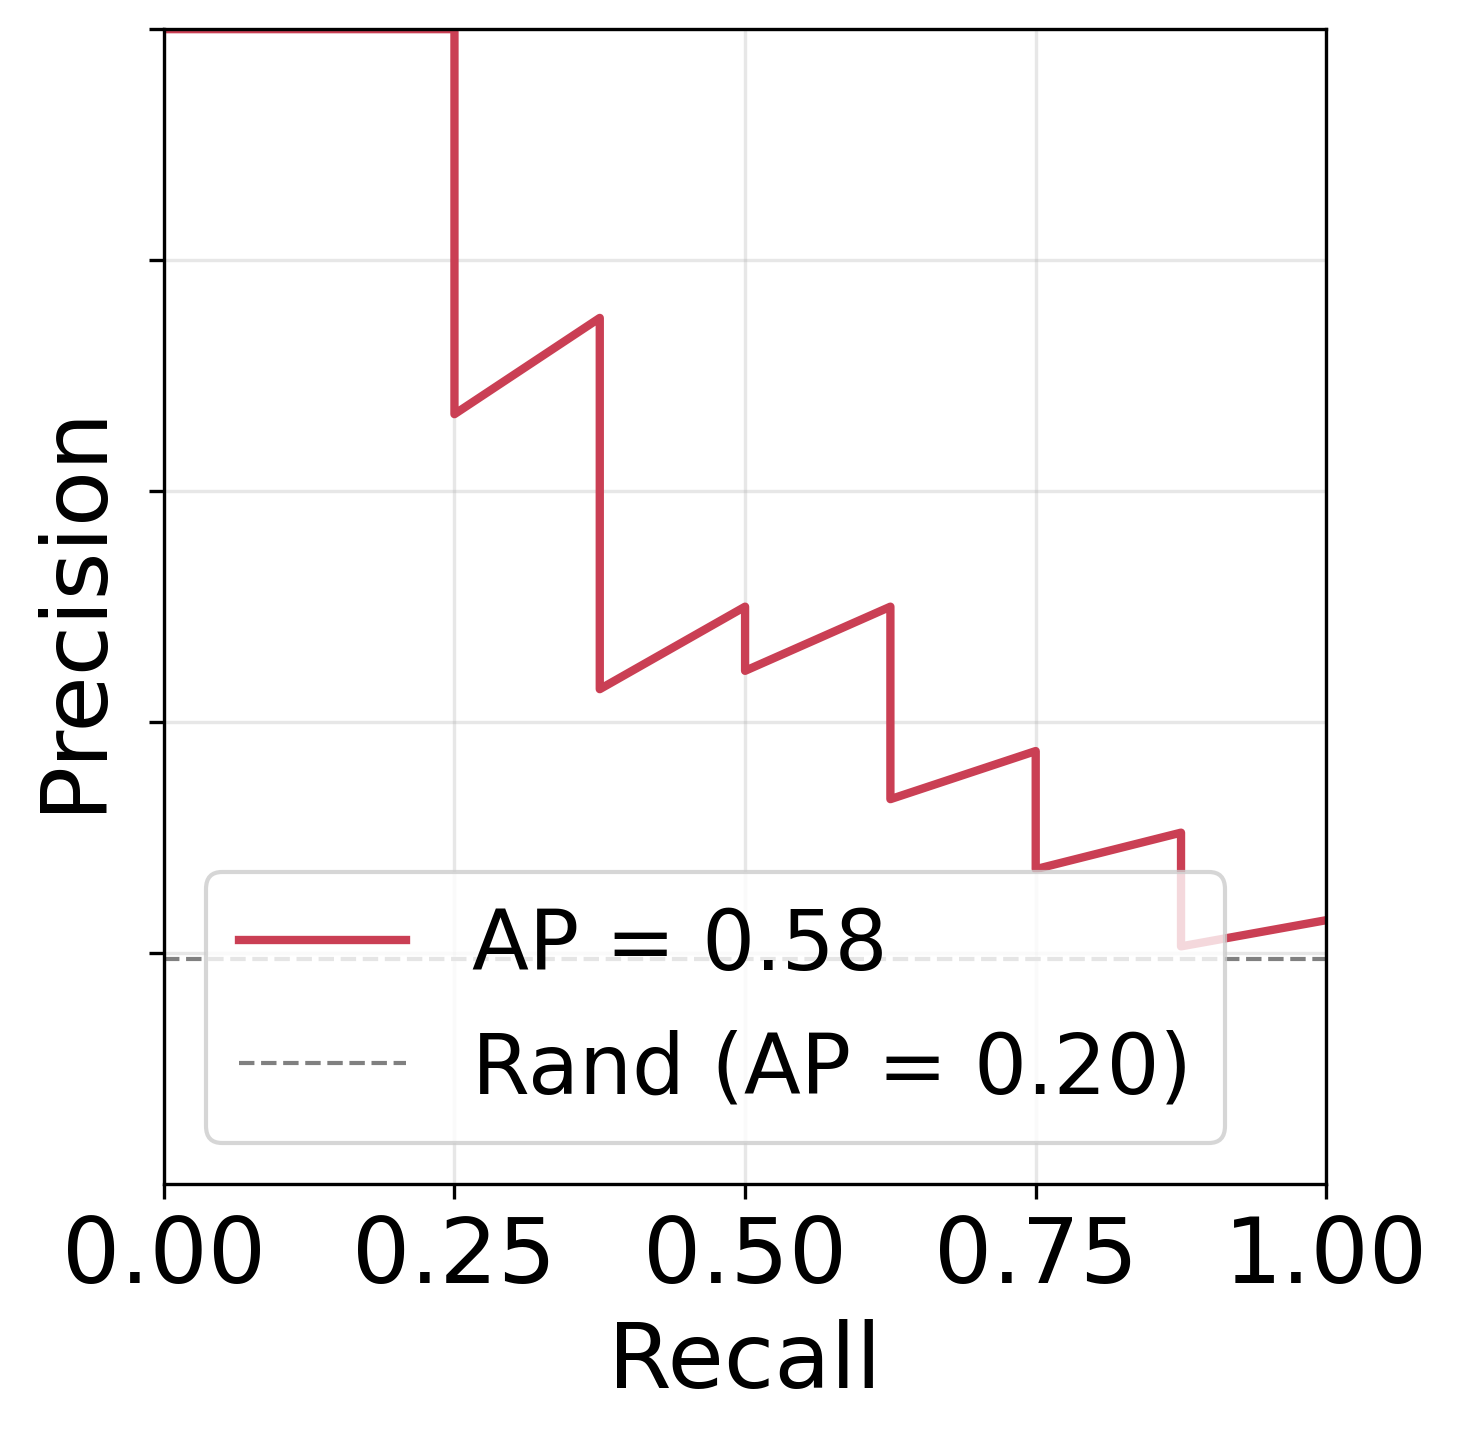

In [55]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs_subset["combo"] = (retinal_probs_subset["Past Preeclampsia"] * 0.35 + 0.15 *((retinal_probs_subset["Nulliparity?"]) * (retinal_probs_subset["Age "] > 37).astype(int)))
retinal_probs_subset_t = retinal_probs_subset[["label","retinal","combo"]]

if all_labels:
    get_test_pr(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                color="#CA3F54", rand=True,
                x_label=True, y_label=True, x_ticks=True, y_ticks=False
               );
else:
    get_test_pr(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                color="#CA3F54", rand=True,
                x_label=True, y_label=True, x_ticks=True, y_ticks=False
               );

plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_{strat_type}_pr.svg')
plt.show()